In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!ls /content/drive/MyDrive/mini_project/split_dataset

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [5]:

train_path = r"D:\mini_project\split_dataset\train"
val_path   = r"D:\mini_project\split_dataset\val"
test_path  = r"D:\mini_project\split_dataset\test"

DATA GENERATORS

In [8]:
train_gen = ImageDataGenerator(rescale=1./255)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 10606 images belonging to 3 classes.
Found 2273 images belonging to 3 classes.


LOAD VGG MODEL-1

In [9]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

TRAIN MODEL

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

TESTING ACCURACY

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("vgg16.keras")  # change filename if different

test_path = "split_dataset/test"

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=False
)

loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

Found 2274 images belonging to 3 classes.
72/72 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.7449 - loss: 0.5529
Test Accuracy: 0.744942843914032


In [ ]:
model.save("/content/drive/MyDrive/mini_project/vgg16.keras")

XCEPTION MODEL


In [6]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load pretrained model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(3, activation='softmax')(x)

# Final model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

TRANING THE MODEL

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

TEXT ACCURACY

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("xception.keras")  # change filename if different

test_path = "split_dataset/test"

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=False
)

loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

Found 2274 images belonging to 3 classes.
72/72 ━━━━━━━━━━━━━━━━━━━━ 572s 8s/step - accuracy: 0.8936 - loss: 0.2843
Test Accuracy: 0.8935796022415161


In [ ]:
model.save("/content/drive/MyDrive/mini_project/xception.keras")

TESTING THE MODELS

In [3]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import numpy as np
import cv2

model = load_model("xception.keras")

img_path = r"split_dataset/test/covid-19/COVID-74.png"

# -------- Load Image --------
img = cv2.imread(img_path)
img_resized = cv2.resize(img, (224,224))

# -------- Check if image is grayscale-like --------
gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

# Calculate color variation
color_diff = np.mean(np.abs(img_resized[:,:,0] - img_resized[:,:,1]))

# Threshold (tune if needed)
if color_diff > 15:
    print("⚠️ Irrelevant Input (Not a Chest X-ray Image)")
else:
    # -------- Normal Prediction --------
    img_array = img_resized / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    class_names = ["covid-19", "normal", "pneumonia"]

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    print("Predicted Disease:", predicted_class)
    print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Disease: covid-19
Confidence: 0.8847197


COMPLETE TESTING CODE (xception_MODEL)

Found 2274 images belonging to 3 classes.
72/72 ━━━━━━━━━━━━━━━━━━━━ 477s 7s/step

Actual vs Predicted Table:

         Actual  Predicted
0      covid-19   covid-19
1      covid-19   covid-19
2      covid-19     normal
3      covid-19   covid-19
4      covid-19   covid-19
...         ...        ...
2269  pneumonia     normal
2270  pneumonia  pneumonia
2271  pneumonia     normal
2272  pneumonia  pneumonia
2273  pneumonia  pneumonia

[2274 rows x 2 columns]

Test Accuracy: 0.8935795954265612

Confusion Matrix:

[[ 373  169    1]
 [  29 1493    7]
 [   3   33  166]]


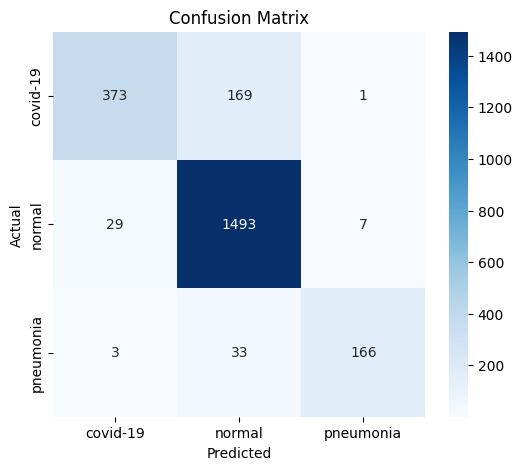

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, accuracy_score

# -------- Load Model --------
model = load_model("xception.keras")   # change to vgg16_model.keras if needed

# -------- Test Data Generator --------
test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# -------- Make Predictions --------
predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)

# -------- Actual Labels --------
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

# -------- Actual vs Predicted Table --------
results = pd.DataFrame({
    "Actual": [class_labels[i] for i in true_classes],
    "Predicted": [class_labels[i] for i in predicted_classes]
})

print("\nActual vs Predicted Table:\n")
print(results)

# -------- Accuracy --------
accuracy = accuracy_score(true_classes, predicted_classes)
print("\nTest Accuracy:", accuracy)

# -------- Confusion Matrix --------
cm = confusion_matrix(true_classes, predicted_classes)

print("\nConfusion Matrix:\n")
print(cm)

# -------- Plot Confusion Matrix --------
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

COMPLETE TESTING CODE (Vgg16_MODEL)

Found 2274 images belonging to 3 classes.
72/72 ━━━━━━━━━━━━━━━━━━━━ 267s 4s/step
Test Accuracy: 0.7449428320140721


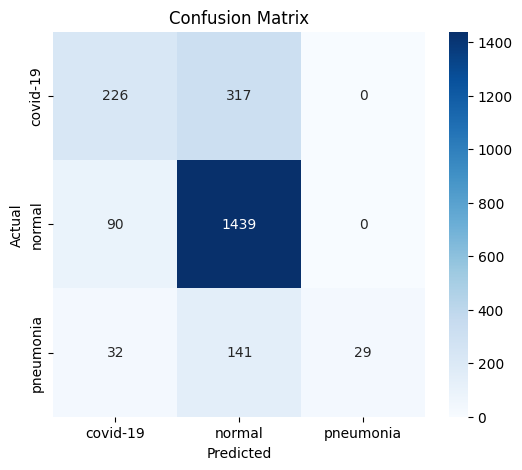

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, accuracy_score

# -------- Load Model --------
model = load_model("vgg16.keras")

# -------- Test Dataset Path --------
test_path = "split_dataset/test"

# -------- Test Data Generator --------
test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# -------- Make Predictions --------
predictions = model.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

# -------- Accuracy --------
acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", acc)

# -------- Confusion Matrix --------
cm = confusion_matrix(y_true, y_pred)

class_labels = list(test_data.class_indices.keys())

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()